<a href="https://colab.research.google.com/github/sujithakoritala/Student-Performance-Analytics/blob/main/BLACKBUCKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from google.colab import data_table, files

# Enable interactive data table view in Google Colab
data_table.enable_dataframe_formatter()
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
def generate_student_data(num_records=200, random_seed=42):
    """
    Generates a synthetic dataset containing academic and behavioral indicators.
    """
    np.random.seed(random_seed)

    student_ids = [f"STD_{1000 + i}" for i in range(num_records)]
    study_hours = np.round(np.random.normal(loc=15, scale=5, size=num_records), 1)
    study_hours = np.clip(study_hours, 2, 40)  # Bound values between 2 and 40 hrs

    attendance = np.round(np.random.uniform(50, 100, size=num_records), 1)
    past_gpa = np.round(np.random.uniform(1.5, 4.0, size=num_records), 2)
    sleep_hours = np.round(np.random.normal(loc=7, scale=1.2, size=num_records), 1)
    extra_curricular = np.random.choice(["Yes", "No"], size=num_records, p=[0.4, 0.6])

    # Target variable generation (Final Exam Score) with logical correlation
    noise = np.random.normal(0, 5, size=num_records)
    raw_score = (study_hours * 1.5) + (attendance * 0.4) + (past_gpa * 8) + noise
    final_score = np.round(np.clip(raw_score, 0, 100), 1)

    df = pd.DataFrame({
        'StudentID': student_ids,
        'StudyHours_PerWeek': study_hours,
        'Attendance_Rate': attendance,
        'Past_GPA': past_gpa,
        'SleepHours_PerNight': sleep_hours,
        'Extracurricular': extra_curricular,
        'Final_Score': final_score
    })

    return df

# Initialize dataset
df_raw = generate_student_data(num_records=250)
print(f"[INFO] Dataset loaded successfully with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.\n")


[INFO] Dataset loaded successfully with 250 rows and 7 columns.



In [3]:
def preprocess_data(df):
    """
    Cleans dataset, encodes categorical variables, and engineers performance target labels.
    """
    df_clean = df.copy()

    # Categorize performance into binary target: 1 (High Performer) vs 0 (Needs Support)
    # Threshold set at 75% final score
    df_clean['Performance_Class'] = np.where(df_clean['Final_Score'] >= 75.0, 1, 0)

    # Binary encoding for categorical column
    df_clean['Extracurricular_Enc'] = df_clean['Extracurricular'].map({'Yes': 1, 'No': 0})

    return df_clean

df_processed = preprocess_data(df_raw)

In [4]:
def print_summary_statistics(df):
    """Prints core descriptive statistics of student academic indicators."""
    print("=================================================================")
    print("                 STUDENT DESCRIPTIVE ANALYTICS                   ")
    print("=================================================================")
    stats = df[['StudyHours_PerWeek', 'Attendance_Rate', 'Past_GPA', 'Final_Score']].describe()
    print(stats)
    print("=================================================================\n")

print_summary_statistics(df_processed)

# Interactive Colab Table Display
df_processed.head(10)


                 STUDENT DESCRIPTIVE ANALYTICS                   
       StudyHours_PerWeek  Attendance_Rate    Past_GPA  Final_Score
count          250.000000       250.000000  250.000000    250.00000
mean            14.989200        76.111600    2.698360     74.72840
std              4.830709        15.187256    0.710785     12.35164
min              2.000000        50.500000    1.510000     46.40000
25%             11.600000        64.025000    2.040000     67.02500
50%             15.300000        77.550000    2.670000     74.95000
75%             17.900000        89.425000    3.325000     83.12500
max             34.300000       100.000000    3.970000    100.00000



,StudentID,StudyHours_PerWeek,Attendance_Rate,Past_GPA,SleepHours_PerNight,Extracurricular,Final_Score,Performance_Class,Extracurricular_Enc
0,STD_1000,17.5,83.0,2.49,5.8,No,79.8,1,0
1,STD_1001,14.3,64.0,3.06,5.0,No,65.1,0,0
2,STD_1002,18.2,97.7,3.66,8.0,Yes,100.0,1,1
3,STD_1003,22.6,86.9,3.87,7.1,No,97.2,1,0
4,STD_1004,13.8,77.7,1.87,5.5,No,59.0,0,0
5,STD_1005,13.8,80.6,3.82,5.4,No,81.4,1,0
6,STD_1006,22.9,71.0,2.73,6.6,No,92.1,1,0
7,STD_1007,18.8,62.4,2.15,9.0,No,74.6,0,0
8,STD_1008,12.7,67.8,2.65,6.7,No,65.6,0,0
9,STD_1009,17.7,87.9,3.95,5.2,No,91.6,1,0


/tmp/ipykernel_452/3079999762.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Class', y='Attendance_Rate', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_452/3079999762.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Needs Support (<75)', 'High Performer (>=75)'])
/tmp/ipykernel_452/3079999762.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Performance_Class', ax=axes[1, 1], palette='crest')
/tmp/ipykernel_452/3079999762.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

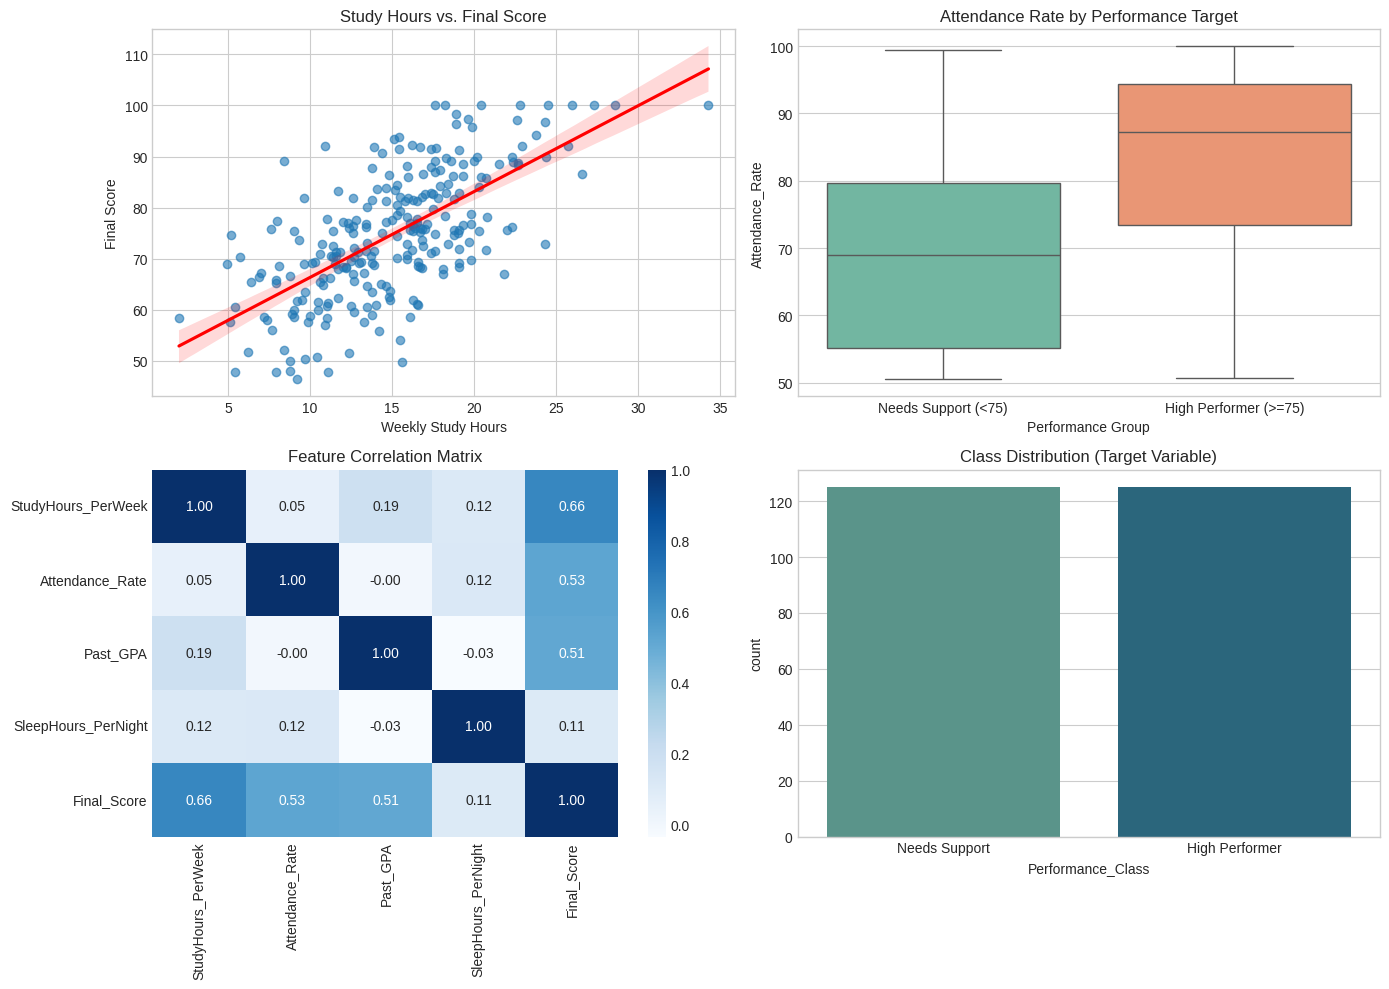

In [5]:
def generate_analytics_plots(df):
    """Generates a 4-panel exploratory visualization dashboard."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Study Hours vs Final Score (Scatter with Regression Line)
    sns.regplot(data=df, x='StudyHours_PerWeek', y='Final_Score', ax=axes[0, 0],
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[0, 0].set_title('Study Hours vs. Final Score')
    axes[0, 0].set_xlabel('Weekly Study Hours')
    axes[0, 0].set_ylabel('Final Score')

    # Plot 2: Attendance Rate Distribution by Performance Class
    sns.boxplot(data=df, x='Performance_Class', y='Attendance_Rate', ax=axes[0, 1], palette='Set2')
    axes[0, 1].set_title('Attendance Rate by Performance Target')
    axes[0, 1].set_xticklabels(['Needs Support (<75)', 'High Performer (>=75)'])
    axes[0, 1].set_xlabel('Performance Group')

    # Plot 3: Feature Correlation Heatmap
    corr_features = df[['StudyHours_PerWeek', 'Attendance_Rate', 'Past_GPA', 'SleepHours_PerNight', 'Final_Score']].corr()
    sns.heatmap(corr_features, annot=True, cmap='Blues', fmt='.2f', ax=axes[1, 0])
    axes[1, 0].set_title('Feature Correlation Matrix')

    # Plot 4: Target Class Balance
    sns.countplot(data=df, x='Performance_Class', ax=axes[1, 1], palette='crest')
    axes[1, 1].set_title('Class Distribution (Target Variable)')
    axes[1, 1].set_xticklabels(['Needs Support', 'High Performer'])

    plt.tight_layout()
    plt.show()

generate_analytics_plots(df_processed)

             MACHINE LEARNING EVALUATION METRICS                 
Model Accuracy Score: 80.00%

Classification Report:
                precision    recall  f1-score   support

 Needs Support       0.83      0.76      0.79        25
High Performer       0.78      0.84      0.81        25

      accuracy                           0.80        50
     macro avg       0.80      0.80      0.80        50
  weighted avg       0.80      0.80      0.80        50




/tmp/ipykernel_452/905266683.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


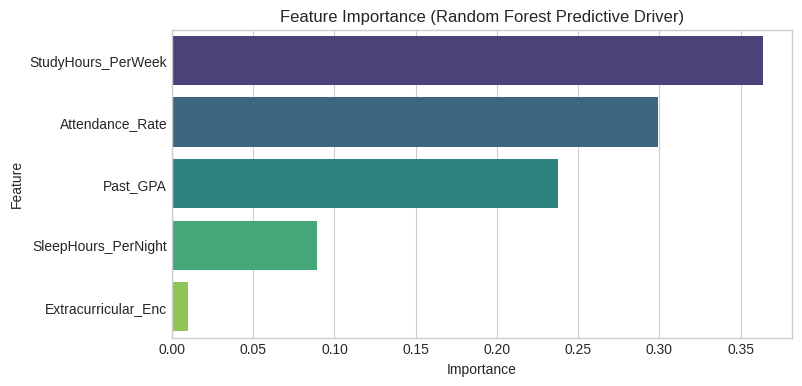

In [6]:
feature_cols = ['StudyHours_PerWeek', 'Attendance_Rate', 'Past_GPA', 'SleepHours_PerNight', 'Extracurricular_Enc']
X = df_processed[feature_cols]
y = df_processed['Performance_Class']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Initialization and Training
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=================================================================")
print("             MACHINE LEARNING EVALUATION METRICS                 ")
print("=================================================================")
print(f"Model Accuracy Score: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Needs Support', 'High Performer']))
print("=================================================================\n")

# Feature Importance Breakdown
importances = rf_classifier.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest Predictive Driver)')
plt.show()


In [7]:
export_filename = "Student_Performance_Analytics_Report.csv"
df_processed.to_csv(export_filename, index=False)
print(f"[INFO] Report file generated: {export_filename}")

# Automatic file download trigger in Google Colab
files.download(export_filename)

[INFO] Report file generated: Student_Performance_Analytics_Report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>